In [5]:
from pathlib import Path
import rasterio
import numpy as np

# 🔧 Параметри
threshold = 2000

# 📁 Папки
acc_folder = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/flow_outputs")
output_folder = acc_folder.parent / "stream_raster"
output_folder.mkdir(exist_ok=True)

accum_files = sorted(acc_folder.glob("*_d8_accum.tif"))
print("Знайдено файлів:", len(accum_files))
for f in accum_files:
    print("🧾", f.name)

# 🔁 Генерація stream_raster
for accum_raster in accum_files:
    name = accum_raster.stem.replace("_d8_accum", "")
    stream_raster_path = output_folder / f"{name}_stream_raster_2000.tif"

    print(f"🌊 Обробка {name} — поріг накопичення: {threshold}")

    with rasterio.open(accum_raster) as src:
        acc_data = src.read(1)
        meta = src.meta.copy()

    stream = np.where(acc_data >= threshold, 1, 0).astype("uint8")

    meta.update(
        dtype="uint8",
        count=1,
        compress="lzw",
        nodata=255
    )

    with rasterio.open(stream_raster_path, "w", **meta) as dst:
        dst.write(stream, 1)

    print(f"✅ Збережено: {stream_raster_path}")

print(f"\n🎉 Усі stream rasters збережено в: {output_folder}")


Знайдено файлів: 7
🧾 alos_dem_utm32635_d8_accum.tif
🧾 aster_dem_utm32635_d8_accum.tif
🧾 copernicus_dеm_utm32635_d8_accum.tif
🧾 fab_dem_utm32635_d8_accum.tif
🧾 nasa_dem_utm32635_d8_accum.tif
🧾 srtm_dem_utm32635_d8_accum.tif
🧾 tan_dem_utm32635_d8_accum.tif
🌊 Обробка alos_dem_utm32635 — поріг накопичення: 2000
✅ Збережено: /mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/stream_raster/alos_dem_utm32635_stream_raster_2000.tif
🌊 Обробка aster_dem_utm32635 — поріг накопичення: 2000
✅ Збережено: /mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/stream_raster/aster_dem_utm32635_stream_raster_2000.tif
🌊 Обробка copernicus_dеm_utm32635 — поріг накопичення: 2000
✅ Збережено: /mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/stream_raster/copernicus_dеm_utm32635_stream_raster_2000.tif
🌊 Обробка fab_dem_utm32635 — поріг накопичення: 2000
✅ Збережено: /mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/stream_raster/fab_dem_utm32

📁 Файл: fab_dem_utm32635_stream_raster_2000.tif
📐 Розмір: (1836, 1191)
📈 Унікальні значення: [0 1]


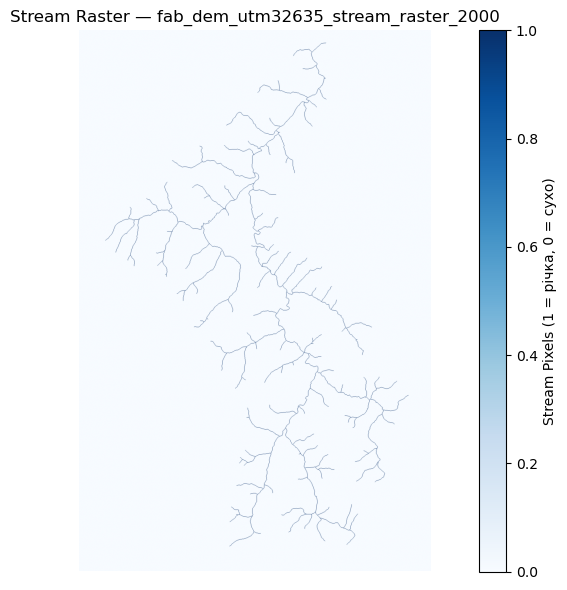

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 🔧 Шлях до stream_raster
stream_path = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/stream_raster/fab_dem_utm32635_stream_raster_2000.tif")

# 📖 Читання
with rasterio.open(stream_path) as src:
    stream_data = src.read(1)
    profile = src.profile

# 📊 Інформація
print(f"📁 Файл: {stream_path.name}")
print(f"📐 Розмір: {stream_data.shape}")
print(f"📈 Унікальні значення: {np.unique(stream_data)}")

# 🖼️ Візуалізація
plt.figure(figsize=(10, 6))
plt.title(f"Stream Raster — {stream_path.stem}")
plt.imshow(stream_data, cmap="Blues")
plt.colorbar(label="Stream Pixels (1 = річка, 0 = сухо)")
plt.axis("off")
plt.tight_layout()
plt.show()
